<a href="https://colab.research.google.com/github/Nik2416/Time-Series/blob/main/Time_Series_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


TIME SERIES ANALYSIS: Apple


[*********************100%***********************]  1 of 1 completed


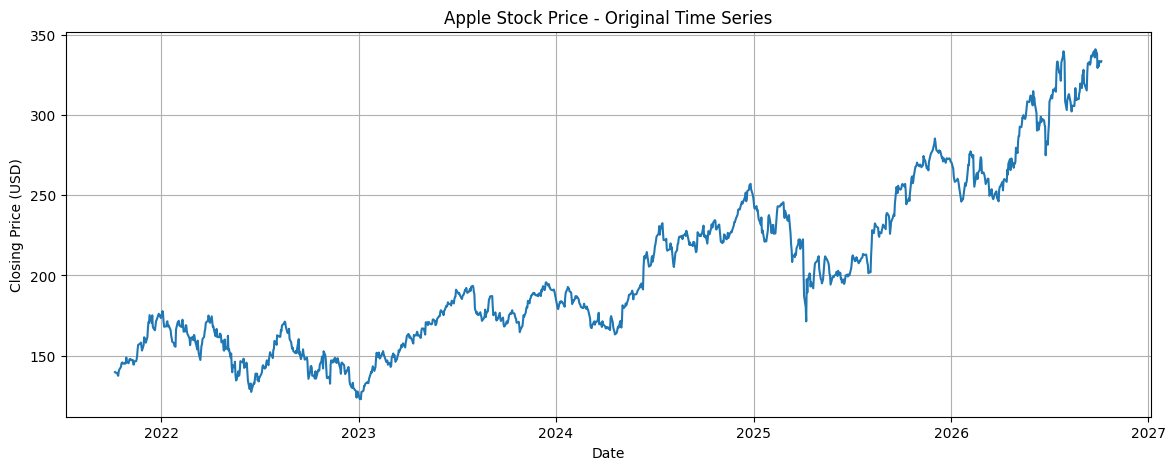

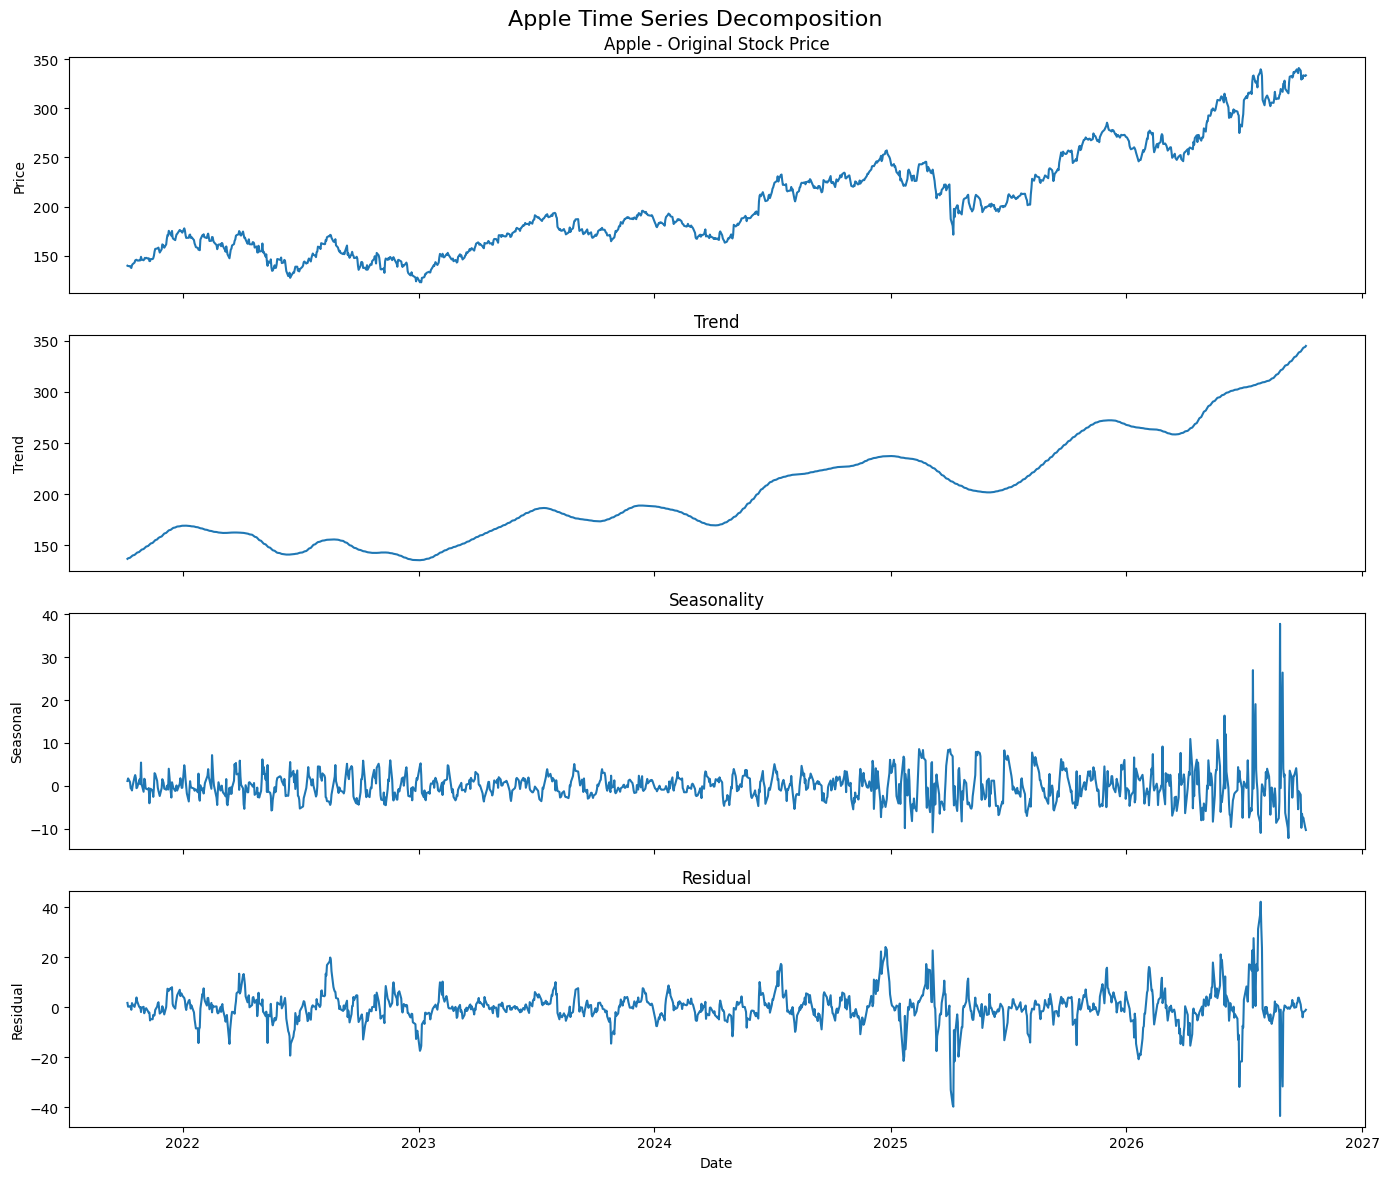


Basic Information:
Starting Price : $139.76
Ending Price   : $333.63
Overall Change : 138.71%

Interpretation:
Trend      : Overall upward trend.
Seasonality: Strength = 0.213
             Moderate seasonal pattern.
Residual   : Standard deviation = 6.735
             Represents random/unexplained fluctuations after removing trend and seasonality.

TIME SERIES ANALYSIS: Microsoft


[*********************100%***********************]  1 of 1 completed


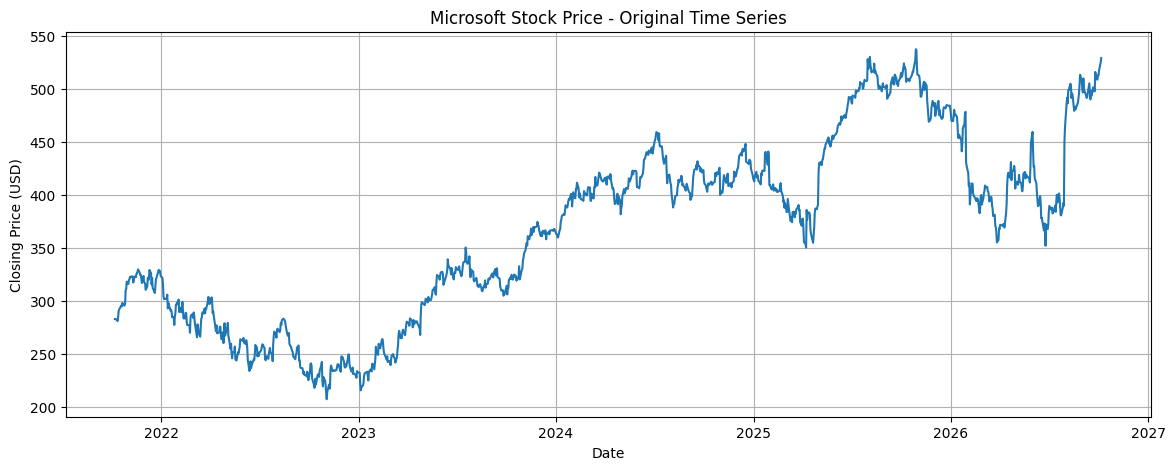

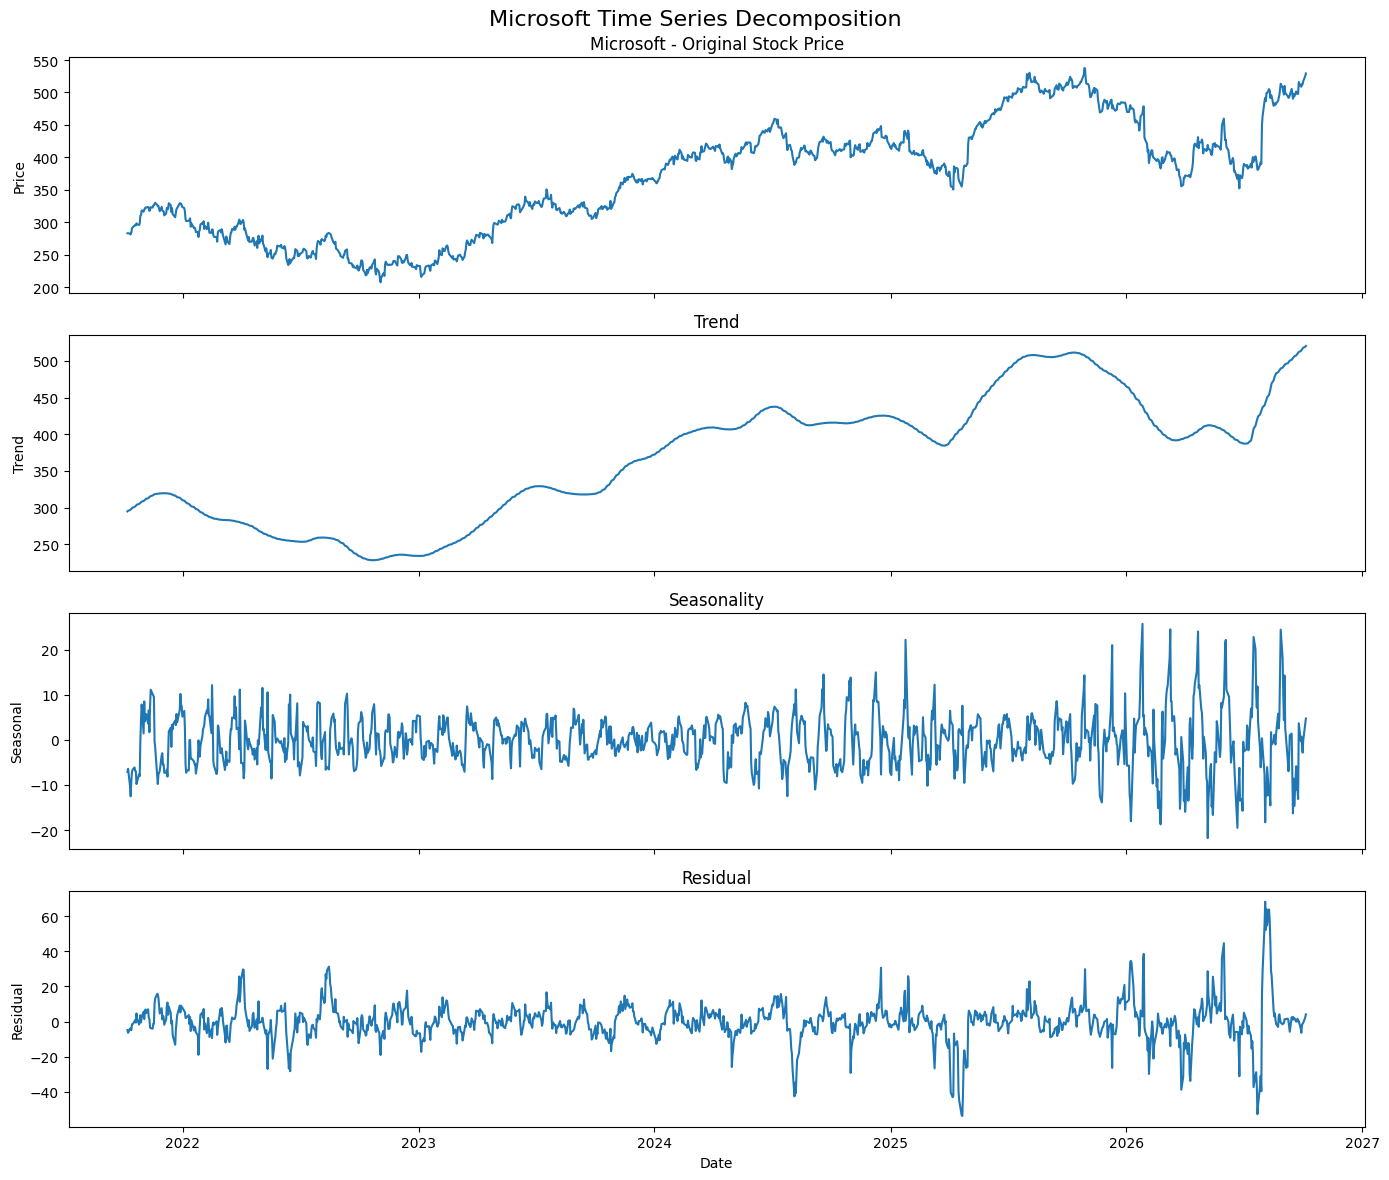


Basic Information:
Starting Price : $282.98
Ending Price   : $529.30
Overall Change : 87.05%

Interpretation:
Trend      : Overall upward trend.
Seasonality: Strength = 0.212
             Moderate seasonal pattern.
Residual   : Standard deviation = 11.124
             Represents random/unexplained fluctuations after removing trend and seasonality.

TIME SERIES ANALYSIS: Tesla


[*********************100%***********************]  1 of 1 completed


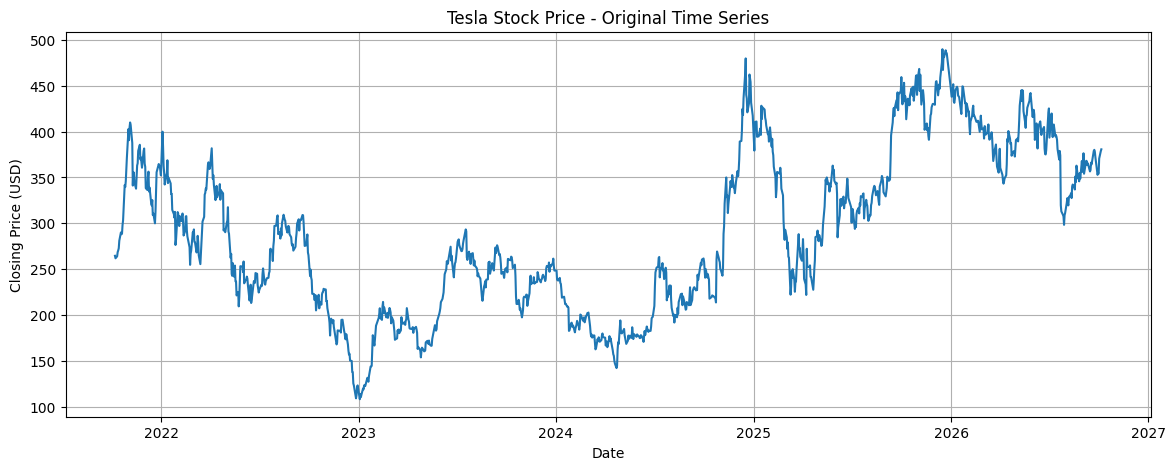

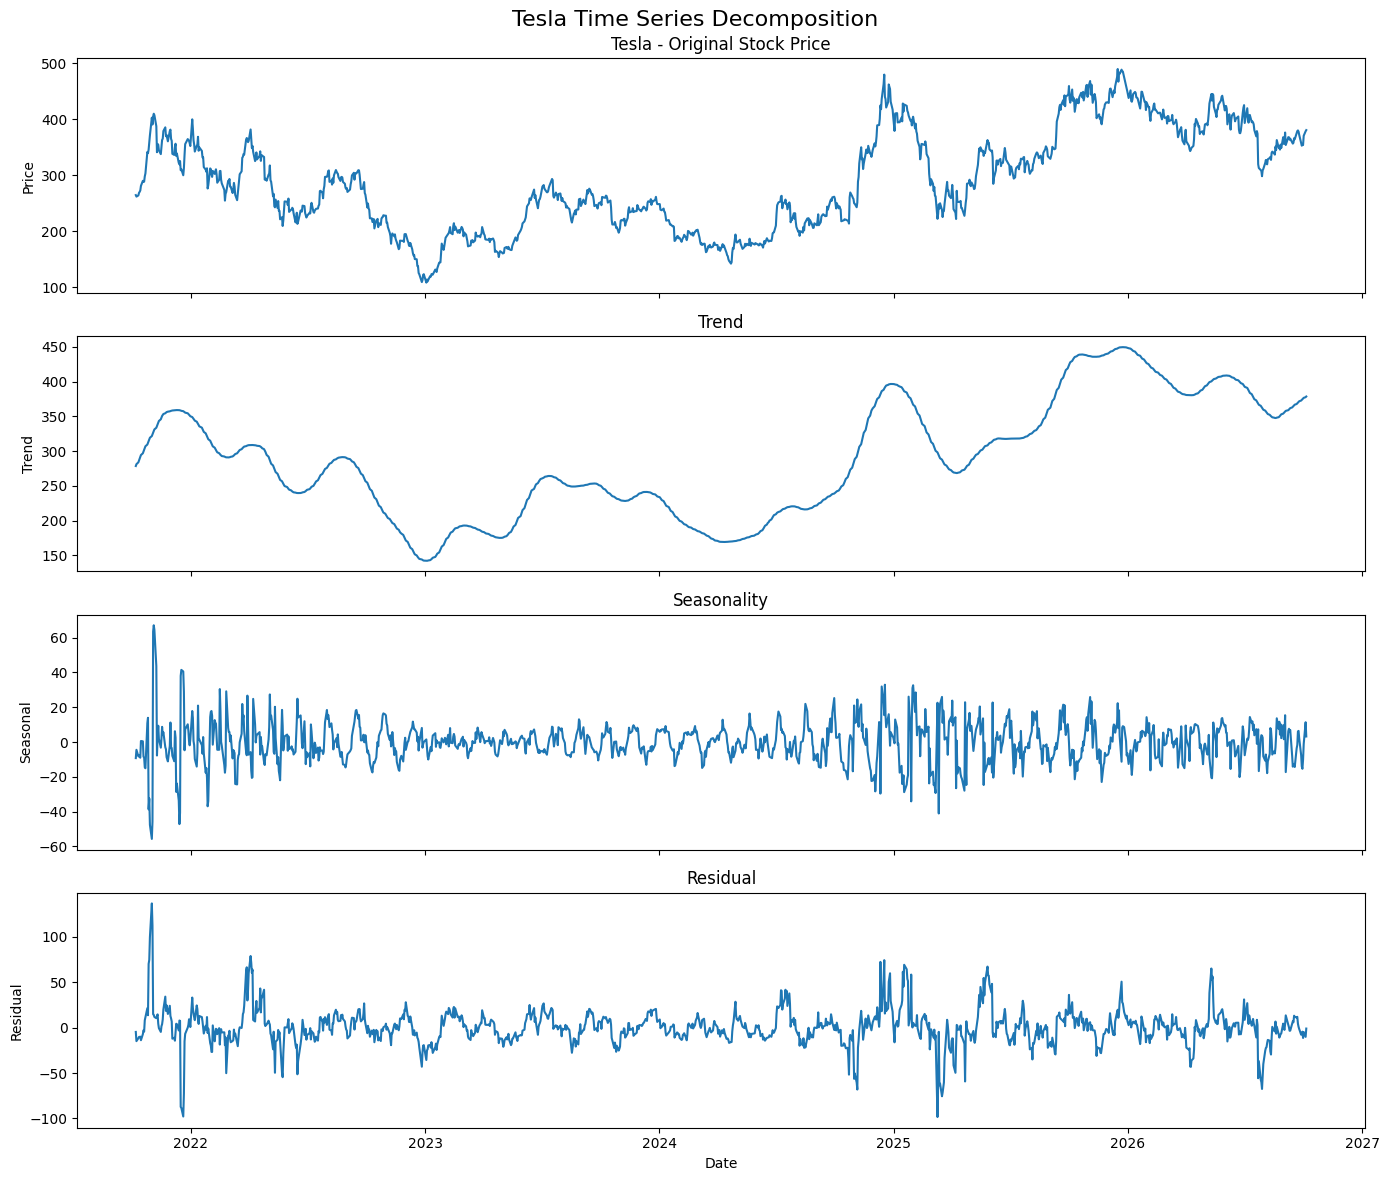


Basic Information:
Starting Price : $264.54
Ending Price   : $380.68
Overall Change : 43.90%

Interpretation:
Trend      : Overall upward trend.
Seasonality: Strength = 0.244
             Moderate seasonal pattern.
Residual   : Standard deviation = 19.870
             Represents random/unexplained fluctuations after removing trend and seasonality.


In [1]:
# ==========================================
# TIME SERIES ANALYSIS OF 3 COMPANIES
# Trend, Seasonality and Residual
# ==========================================

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL


# ------------------------------------------
# 1. Companies
# ------------------------------------------

companies = {
    "Apple": "AAPL",
    "Microsoft": "MSFT",
    "Tesla": "TSLA"
}


# ------------------------------------------
# 2. Download and analyze each company
# ------------------------------------------

for company_name, ticker in companies.items():

    print("\n" + "=" * 60)
    print(f"TIME SERIES ANALYSIS: {company_name}")
    print("=" * 60)

    # Download 5 years of historical data
    data = yf.download(
        ticker,
        period="5y",
        interval="1d",
        auto_adjust=True
    )

    # --------------------------------------
    # 3. Select closing price
    # --------------------------------------

    close = data["Close"]

    # Handle possible multi-column format
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]

    # Remove missing values
    close = close.dropna()

    # --------------------------------------
    # 4. Plot original time series
    # --------------------------------------

    plt.figure(figsize=(14, 5))

    plt.plot(close)

    plt.title(f"{company_name} Stock Price - Original Time Series")
    plt.xlabel("Date")
    plt.ylabel("Closing Price (USD)")
    plt.grid(True)

    plt.show()


    # --------------------------------------
    # 5. STL Decomposition
    # --------------------------------------

    # period = 30 means we are looking
    # for approximately monthly patterns
    decomposition = STL(
        close,
        period=30,
        robust=True
    ).fit()


    # --------------------------------------
    # 6. Extract components
    # --------------------------------------

    trend = decomposition.trend
    seasonal = decomposition.seasonal
    residual = decomposition.resid


    # --------------------------------------
    # 7. Plot decomposition
    # --------------------------------------

    fig, axes = plt.subplots(
        4,
        1,
        figsize=(14, 12),
        sharex=True
    )

    # Original
    axes[0].plot(close)
    axes[0].set_title(
        f"{company_name} - Original Stock Price"
    )
    axes[0].set_ylabel("Price")

    # Trend
    axes[1].plot(trend)
    axes[1].set_title("Trend")
    axes[1].set_ylabel("Trend")

    # Seasonality
    axes[2].plot(seasonal)
    axes[2].set_title("Seasonality")
    axes[2].set_ylabel("Seasonal")

    # Residual
    axes[3].plot(residual)
    axes[3].set_title("Residual")
    axes[3].set_ylabel("Residual")
    axes[3].set_xlabel("Date")

    plt.suptitle(
        f"{company_name} Time Series Decomposition",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()


    # --------------------------------------
    # 8. Basic numerical information
    # --------------------------------------

    print("\nBasic Information:")

    print(f"Starting Price : ${close.iloc[0]:.2f}")
    print(f"Ending Price   : ${close.iloc[-1]:.2f}")

    percentage_change = (
        (close.iloc[-1] - close.iloc[0])
        / close.iloc[0]
    ) * 100

    print(
        f"Overall Change : {percentage_change:.2f}%"
    )


    # --------------------------------------
    # 9. Interpretation
    # --------------------------------------

    print("\nInterpretation:")

    # Trend
    if trend.iloc[-1] > trend.iloc[0]:
        print("Trend      : Overall upward trend.")
    else:
        print("Trend      : Overall downward trend.")

    # Seasonality
    seasonal_strength = (
        seasonal.var()
        / (seasonal.var() + residual.var())
    )

    print(
        f"Seasonality: Strength = "
        f"{seasonal_strength:.3f}"
    )

    if seasonal_strength > 0.5:
        print(
            "             Strong repeating seasonal pattern."
        )
    elif seasonal_strength > 0.2:
        print(
            "             Moderate seasonal pattern."
        )
    else:
        print(
            "             Weak seasonal pattern."
        )

    # Residual
    residual_std = residual.std()

    print(
        f"Residual   : Standard deviation = "
        f"{residual_std:.3f}"
    )

    print(
        "             Represents random/unexplained "
        "fluctuations after removing trend and seasonality."
    )